In [ ]:
import cv2
import pandas as pd
import numpy as np # Not strictly used here but good to have for general CV/data tasks

def ecriture_yolo_plus_weyl(video_path, yolo_path, weyl_path):
    # Load Weyl data (CSV)
    try:
        # User specified: "Le fichier csv contient en premère lignes les noms des colonnes sur chaque colonnes j'ai numéro de frame, x, y, w, h"
        # We assume these are pixel coordinates (top-left x, y, width, height)
        weyl_df = pd.read_csv(weyl_path)
        weyl_df.columns = ['frame', 'x', 'y', 'w', 'h']
    except Exception as e:
        print(f"Error loading Weyl data from {weyl_path}: {e}")
        return

    # Load YOLO data (TXT)
    yolo_data = []
    try:
        # User specified: "pour les fichiers .txt j'ai sur chaque ligne dès la première ligne frame, numero de frame, x, y, w, h"
        # Based on user's recent comment: "Frame 0: 351.80,128.40,12.43,32.38"
        with open(yolo_path, 'r') as f:
            for line in f:
                line_stripped = line.strip()
                if not line_stripped:
                    continue # Skip empty lines

                parts_colon = line_stripped.split(': ')
                if len(parts_colon) != 2:
                    print(f"Skipping malformed line in {yolo_path} (expected 'Frame X: Y'): {line_stripped}")
                    continue

                frame_part = parts_colon[0].replace('Frame ', '')
                try:
                    frame_num = int(frame_part)
                except ValueError:
                    print(f"Skipping malformed line in {yolo_path} (cannot parse frame number): {line_stripped}")
                    continue

                bbox_parts = parts_colon[1].split(',')
                if len(bbox_parts) == 4:
                    try:
                        x_center, y_center, width, height = map(float, bbox_parts)
                        yolo_data.append([frame_num, x_center, y_center, width, height])
                    except ValueError:
                        print(f"Skipping malformed line in {yolo_path} (cannot parse bbox coordinates): {line_stripped}")
                else:
                    print(f"Skipping line with incorrect number of bbox elements in {yolo_path}: {line_stripped}")
        yolo_df = pd.DataFrame(yolo_data, columns=['frame', 'x', 'y', 'w', 'h'])
    except Exception as e:
        print(f"Error loading YOLO data from {yolo_path}: {e}")
        return

    # Open video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return

    # Get video properties
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Define the codec and create VideoWriter object
    output_video_name = "output_video_with_boxes.mp4"
    # On Colab, 'mp4v' or 'XVID' often works for .mp4. If issues, try other codecs or '.avi' with 'MJPG'.
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_name, fourcc, fps, (frame_width, frame_height))

    if not out.isOpened():
        print(f"Error: Could not create video writer for {output_video_name}. Make sure the codec is supported.")
        cap.release()
        return

    current_frame_idx = 0
    print(f"Starting video processing. Total frames: {total_frames}")

    while True:
        ret, frame = cap.read()
        if not ret:
            break # End of video

        if current_frame_idx % 100 == 0 or current_frame_idx == total_frames - 1:
            print(f"Processing frame {current_frame_idx + 1}/{total_frames}")

        # Filter boxes for the current frame
        weyl_boxes = weyl_df[weyl_df['frame'] == current_frame_idx]
        yolo_boxes = yolo_df[yolo_df['frame'] == current_frame_idx]

        # Colors for drawing (B, G, R)
        YOLO_COLOR = (0, 255, 0) # Green
        WEYL_COLOR = (0, 0, 255) # Red
        LEGEND_COLOR = (255, 255, 255) # White

        # Draw YOLO boxes
        for _, row in yolo_boxes.iterrows():
            # YOLO format: x, y are center coordinates, w, h are width and height
            x_center, y_center, width, height = row['x'], row['y'], row['w'], row['h']

            # Convert center coordinates to top-left corner coordinates
            x1 = int(x_center - width / 2)
            y1 = int(y_center - height / 2)
            x2 = int(x_center + width / 2)
            y2 = int(y_center + height / 2)

            # Clip coordinates to frame boundaries
            x1_clipped = max(0, x1)
            y1_clipped = max(0, y1)
            x2_clipped = min(frame_width, x2)
            y2_clipped = min(frame_height, y2)

            if x1_clipped < x2_clipped and y1_clipped < y2_clipped: # Only draw valid rectangles
                cv2.rectangle(frame, (x1_clipped, y1_clipped), (x2_clipped, y2_clipped), YOLO_COLOR, 2)
                cv2.putText(frame, "YOLO", (x1_clipped, max(20, y1_clipped - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, YOLO_COLOR, 2) # Adjust text position

        # Draw Weyl boxes
        for _, row in weyl_boxes.iterrows():
            # Convert float coordinates to integers for drawing, clip to frame boundaries
            x, y, w, h = int(row['x']), int(row['y']), int(row['w']), int(row['h'])
            x1 = max(0, x)
            y1 = max(0, y)
            x2 = min(frame_width, x + w)
            y2 = min(frame_height, y + h)
            if x1 < x2 and y1 < y2: # Only draw valid rectangles
                cv2.rectangle(frame, (x1, y1), (x2, y2), WEYL_COLOR, 2)
                cv2.putText(frame, "Weyl", (x1, max(20, y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, WEYL_COLOR, 2) # Adjust text position

        # Add legend
        legend_x_start = 10
        legend_y_start = 30
        line_height = 30
        font_scale = 0.7
        font_thickness = 2
        font = cv2.FONT_HERSHEY_SIMPLEX

        # Ensure legend is visible, adjust coordinates if necessary
        # Draw a small background rectangle for the legend to improve readability
        legend_bg_x2 = legend_x_start + 250 # approximate width needed
        legend_bg_y2 = legend_y_start + 2 * line_height + 15 # approximate height needed
        cv2.rectangle(frame, (legend_x_start - 5, legend_y_start - 25), (legend_bg_x2, legend_bg_y2), (0,0,0), -1) # Black background

        cv2.putText(frame, "Legend:", (legend_x_start, legend_y_start), font, font_scale, LEGEND_COLOR, font_thickness)
        cv2.putText(frame, "YOLO: Green Box", (legend_x_start, legend_y_start + line_height), font, font_scale, YOLO_COLOR, font_thickness)
        cv2.putText(frame, "Weyl: Red Box", (legend_x_start, legend_y_start + 2 * line_height), font, font_scale, WEYL_COLOR, font_thickness)

        # Write the frame to the output video
        out.write(frame)

        current_frame_idx += 1

    # Release everything
    cap.release()
    out.release()
    print(f"Processing complete. Output video saved to '{output_video_name}'")

In [ ]:
video_path = "/content/video_stationnage.mp4"
yolo_path = "/content/video_stationnage_tracked_car_boxes.txt"
weyl_path = "/content/video_stationnage_tracking.csv"
ecriture_yolo_plus_weyl(video_path, yolo_path, weyl_path)

Starting video processing. Total frames: 450
Processing frame 1/450
Processing frame 101/450
Processing frame 201/450
Processing frame 301/450
Processing frame 401/450
Processing frame 450/450
Processing complete. Output video saved to 'output_video_with_boxes.mp4'


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calcul_mse(yolo_path, weyl_path):

    # Load Weyl data (CSV)
    try:
        weyl_df = pd.read_csv(weyl_path)
        weyl_df.columns = ['frame', 'x', 'y', 'w', 'h']
        # Calculate center coordinates for Weyl boxes
        weyl_df['cx'] = weyl_df['x'] + weyl_df['w'] / 2
        weyl_df['cy'] = weyl_df['y'] + weyl_df['h'] / 2
    except Exception as e:
        print(f"Error loading Weyl data from {weyl_path}: {e}")
        return

    # Load YOLO data (TXT)
    yolo_data = []
    try:
        with open(yolo_path, 'r') as f:
            for line in f:
                line_stripped = line.strip()
                if not line_stripped:
                    continue # Skip empty lines

                parts_colon = line_stripped.split(': ')
                if len(parts_colon) != 2:
                    print(f"Skipping malformed line in {yolo_path}: {line_stripped}")
                    continue

                frame_part = parts_colon[0].replace('Frame ', '')
                try:
                    frame_num = int(frame_part)
                except ValueError:
                    print(f"Skipping malformed line in {yolo_path} (cannot parse frame number): {line_stripped}")
                    continue

                bbox_parts = parts_colon[1].split(',')
                if len(bbox_parts) == 4:
                    try:
                        # YOLO format: x_center, y_center, width, height (as pixel coordinates from previous context)
                        x_center, y_center, width, height = map(float, bbox_parts)
                        yolo_data.append([frame_num, x_center, y_center, width, height])
                    except ValueError:
                        print(f"Skipping malformed line in {yolo_path} (cannot parse bbox coordinates): {line_stripped}")
                else:
                    print(f"Skipping line with incorrect number of bbox elements in {yolo_path}: {line_stripped}")
        yolo_df = pd.DataFrame(yolo_data, columns=['frame', 'cx', 'cy', 'w', 'h'])
    except Exception as e:
        print(f"Error loading YOLO data from {yolo_path}: {e}")
        return

    # Get all unique frames to iterate through
    all_frames = sorted(list(set(weyl_df['frame'].unique()).union(yolo_df['frame'].unique())))

    mse_percentage_values = []
    frames_with_mse = []
    mse_max = 0

    for frame_idx in all_frames:
        weyl_frame_data = weyl_df[weyl_df['frame'] == frame_idx]
        yolo_frame_data = yolo_df[yolo_df['frame'] == frame_idx]

        if not weyl_frame_data.empty and not yolo_frame_data.empty:
            # Calculate average center and dimensions for Weyl boxes in this frame
            weyl_avg_cx = weyl_frame_data['cx'].mean()
            weyl_avg_cy = weyl_frame_data['cy'].mean()
            weyl_avg_w = weyl_frame_data['w'].mean()
            weyl_avg_h = weyl_frame_data['h'].mean()

            # Calculate average center for YOLO boxes in this frame
            yolo_avg_cx = yolo_frame_data['cx'].mean()
            yolo_avg_cy = yolo_frame_data['cy'].mean()

            # Calculate squared Euclidean distance between average centers
            current_mse_pixel = (weyl_avg_cx - yolo_avg_cx)**2 + (weyl_avg_cy - yolo_avg_cy)**2

            if current_mse_pixel > mse_max:
                mse_max = current_mse_pixel

            # Calculate the squared diagonal of the average Weyl box for this specific frame
            # This will be used as the normalization factor for this frame's MSE.
            frame_squared_diagonal = weyl_avg_w**2 + weyl_avg_h**2

            if frame_squared_diagonal <= 0: # Handle cases where dimensions might be zero or negative
                print(f"Warning: Weyl box has zero or negative dimensions in frame {frame_idx}. Skipping normalization for this frame.")
                continue # Skip frames where normalization is not possible

            # Convert to percentage MSE, normalized by the Weyl box diagonal of the current frame
            current_mse_percentage = current_mse_pixel

            mse_percentage_values.append(current_mse_percentage)
            frames_with_mse.append(frame_idx)

    if not mse_percentage_values:
        print("No frames found with both Weyl and YOLO data for MSE calculation, or no valid normalization factor.")
        return

    for i in range(len(mse_percentage_values)):
        mse_percentage_values[i] = mse_percentage_values[i] / mse_max * 100
        # mse_percentage_values[mse_percentage_values.index(i)] = i

    # Plotting the results
    plt.figure(figsize=(12, 6))
    plt.plot(frames_with_mse, mse_percentage_values, marker='o', linestyle='-', markersize=4)
    plt.title('MSE des Bounding Box sur les centres (Normalisé)')
    plt.xlabel('Frame')
    plt.ylabel('MSE en %')
    plt.grid(True)
    plt.show()

    print(f"{len(frames_with_mse)} frames traitées.")
    print(f"Moyenne MSE totale: {np.mean(mse_percentage_values):.2f}%")
    print(f"Pourcentage Max MSE: {np.max(mse_percentage_values):.2f}%")
    print(f"Pourcentage Min MSE: {np.min(mse_percentage_values):.2f}%")

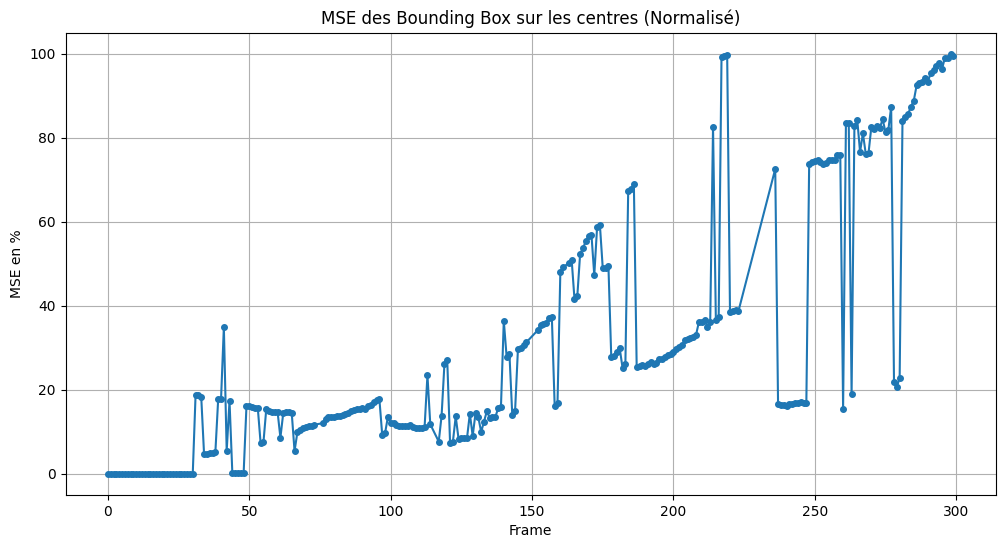

280 frames traitées.
Moyenne MSE totale: 31.44%
Pourcentage Max MSE: 100.00%
Pourcentage Min MSE: 0.00%


In [15]:
yolo_path = "/content/video_personne_person_boxes.txt"
weyl_path = "/content/video_personne_tracking.csv"
calcul_mse(yolo_path, weyl_path)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_iou(boxA, boxB):
    # boxA and boxB are [x1, y1, x2, y2]

    # determine the (x, y)-coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # compute the area of intersection rectangle
    interArea = max(0, xB - xA) * max(0, yB - yA)

    # compute the area of both the prediction and ground-truth rectangles
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # compute the intersection over union by taking the intersection
    # area and dividing it by the sum of prediction + ground-truth
    # areas - the interesection area
    iou = interArea / float(boxAArea + boxBArea - interArea)

    # return the intersection over union value
    return iou

def taux_intersection(yolo_path, weyl_path):
    # Load Weyl data (CSV)
    try:
        weyl_df = pd.read_csv(weyl_path)
        weyl_df.columns = ['frame', 'x', 'y', 'w', 'h']
        # Convert to x1, y1, x2, y2 format for easier IoU calculation
        weyl_df['x1'] = weyl_df['x']
        weyl_df['y1'] = weyl_df['y']
        weyl_df['x2'] = weyl_df['x'] + weyl_df['w']
        weyl_df['y2'] = weyl_df['y'] + weyl_df['h']
    except Exception as e:
        print(f"Error loading Weyl data from {weyl_path}: {e}")
        return

    # Load YOLO data (TXT)
    yolo_data = []
    try:
        with open(yolo_path, 'r') as f:
            for line in f:
                line_stripped = line.strip()
                if not line_stripped:
                    continue # Skip empty lines

                parts_colon = line_stripped.split(': ')
                if len(parts_colon) != 2:
                    print(f"Skipping malformed line in {yolo_path}: {line_stripped}")
                    continue

                frame_part = parts_colon[0].replace('Frame ', '')
                try:
                    frame_num = int(frame_part)
                except ValueError:
                    print(f"Skipping malformed line in {yolo_path} (cannot parse frame number): {line_stripped}")
                    continue

                bbox_parts = parts_colon[1].split(',')
                if len(bbox_parts) == 4:
                    try:
                        # YOLO format: x_center, y_center, width, height
                        x_center, y_center, width, height = map(float, bbox_parts)
                        yolo_data.append([frame_num, x_center, y_center, width, height])
                    except ValueError:
                        print(f"Skipping malformed line in {yolo_path} (cannot parse bbox coordinates): {line_stripped}")
                else:
                    print(f"Skipping line with incorrect number of bbox elements in {yolo_path}: {line_stripped}")
        yolo_df = pd.DataFrame(yolo_data, columns=['frame', 'cx', 'cy', 'w', 'h'])
        # Convert to x1, y1, x2, y2 for IoU calculation
        yolo_df['x1'] = yolo_df['cx'] - yolo_df['w'] / 2
        yolo_df['y1'] = yolo_df['cy'] - yolo_df['h'] / 2
        yolo_df['x2'] = yolo_df['cx'] + yolo_df['w'] / 2
        yolo_df['y2'] = yolo_df['cy'] + yolo_df['h'] / 2
    except Exception as e:
        print(f"Error loading YOLO data from {yolo_path}: {e}")
        return

    # Get all unique frames to iterate through
    all_frames = sorted(list(set(weyl_df['frame'].unique()).union(yolo_df['frame'].unique())))

    iou_values = []
    frames_with_iou = []

    for frame_idx in all_frames:
        weyl_frame_data = weyl_df[weyl_df['frame'] == frame_idx]
        yolo_frame_data = yolo_df[yolo_df['frame'] == frame_idx]

        if not weyl_frame_data.empty and not yolo_frame_data.empty:
            # Calculate average Weyl box for this frame
            avg_weyl_x1 = weyl_frame_data['x1'].mean()
            avg_weyl_y1 = weyl_frame_data['y1'].mean()
            avg_weyl_x2 = weyl_frame_data['x2'].mean()
            avg_weyl_y2 = weyl_frame_data['y2'].mean()
            avg_weyl_box = [avg_weyl_x1, avg_weyl_y1, avg_weyl_x2, avg_weyl_y2]

            # Calculate average YOLO box for this frame (using its original center and dims)
            avg_yolo_cx = yolo_frame_data['cx'].mean()
            avg_yolo_cy = yolo_frame_data['cy'].mean()
            avg_yolo_w = yolo_frame_data['w'].mean()
            avg_yolo_h = yolo_frame_data['h'].mean()

            # Apply the constraint: 'force the YOLO rectangle not to be larger than the size of the Weyl rectangle.'
            # Adjust YOLO dimensions if they exceed Weyl's, keeping YOLO's original center
            weyl_box_width = avg_weyl_x2 - avg_weyl_x1
            weyl_box_height = avg_weyl_y2 - avg_weyl_y1

            adjusted_yolo_w = min(avg_yolo_w, weyl_box_width)
            adjusted_yolo_h = min(avg_yolo_h, weyl_box_height)

            # Recalculate adjusted YOLO box coordinates
            adjusted_yolo_x1 = avg_yolo_cx - adjusted_yolo_w / 2
            adjusted_yolo_y1 = avg_yolo_cy - adjusted_yolo_h / 2
            adjusted_yolo_x2 = avg_yolo_cx + adjusted_yolo_w / 2
            adjusted_yolo_y2 = avg_yolo_cy + adjusted_yolo_h / 2
            adjusted_yolo_box = [adjusted_yolo_x1, adjusted_yolo_y1, adjusted_yolo_x2, adjusted_yolo_y2]

            current_iou = calculate_iou(avg_weyl_box, adjusted_yolo_box)
            iou_values.append(current_iou)
            frames_with_iou.append(frame_idx)

    if not iou_values:
        print("No frames found with both Weyl and YOLO data for IoU calculation.")
        return

    # Plotting the results
    plt.figure(figsize=(12, 6))
    plt.plot(frames_with_iou, iou_values, marker='o', linestyle='-', markersize=4)
    plt.title('Taux d\'Intersection (IoU) des Bounding Box par Frame')
    plt.xlabel('Frame Number')
    plt.ylabel('IoU')
    plt.grid(True)
    plt.ylim(0, 1) # IoU is between 0 and 1
    plt.show()

    print(f"{len(frames_with_iou)} frames traitées.")
    print(f"Moyenne IoU totale: {np.mean(iou_values):.2f}")
    print(f"Max IoU: {np.max(iou_values):.2f}")
    print(f"Min IoU: {np.min(iou_values):.2f}")



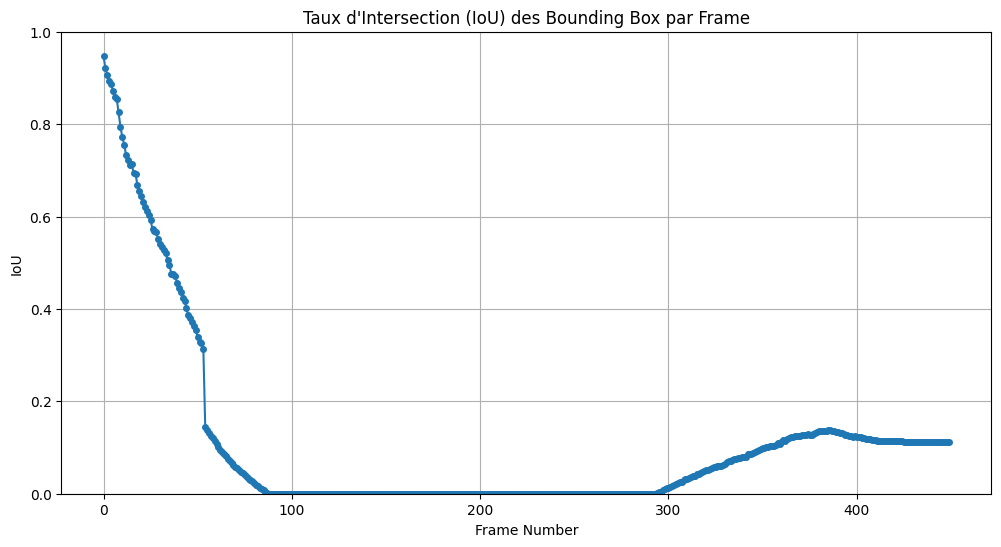

450 frames traitées.
Moyenne IoU totale: 0.11
Max IoU: 0.95
Min IoU: 0.00


In [ ]:
yolo_path = "/content/video_stationnage_tracked_car_boxes.txt"
weyl_path = "/content/video_stationnage_tracking.csv"
taux_intersection(yolo_path, weyl_path)